In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("melb_data.csv")

display(df.head())
print(df.info())

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  str    
 1   Address        13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  str    
 6   SellerG        13580 non-null  str    
 7   Date           13580 non-null  str    
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  str    
 17  Lattitude      13580 non-null  float64
 18  Longtitude     13

In [2]:
# Her sütunda kaç tane eksik (NaN) değer var?
print(df.isnull().sum())

Suburb              0
Address             0
Rooms               0
Type                0
Price               0
Method              0
SellerG             0
Date                0
Distance            0
Postcode            0
Bedroom2            0
Bathroom            0
Car                62
Landsize            0
BuildingArea     6450
YearBuilt        5375
CouncilArea      1369
Lattitude           0
Longtitude          0
Regionname          0
Propertycount       0
dtype: int64


In [3]:


# CAR verisinde az sayıda eksik olduğu için siliyoruz.
df = df.dropna(subset=['Car'])

# 'BuildingArea' ve 'YearBuilt' sütunlarındaki boşlukların sayısı fazla olduğundan medyan ile dolduruyoruz.
df['BuildingArea'] = df['BuildingArea'].fillna(df['BuildingArea'].median())
df['YearBuilt'] = df['YearBuilt'].fillna(df['YearBuilt'].median())

# 'CouncilArea' eksiklerini de mod ile dolduralım.
df['CouncilArea'] = df['CouncilArea'].fillna(df['CouncilArea'].mode()[0])

#kontrol edelim.
print(df.isnull().sum().sum())

0


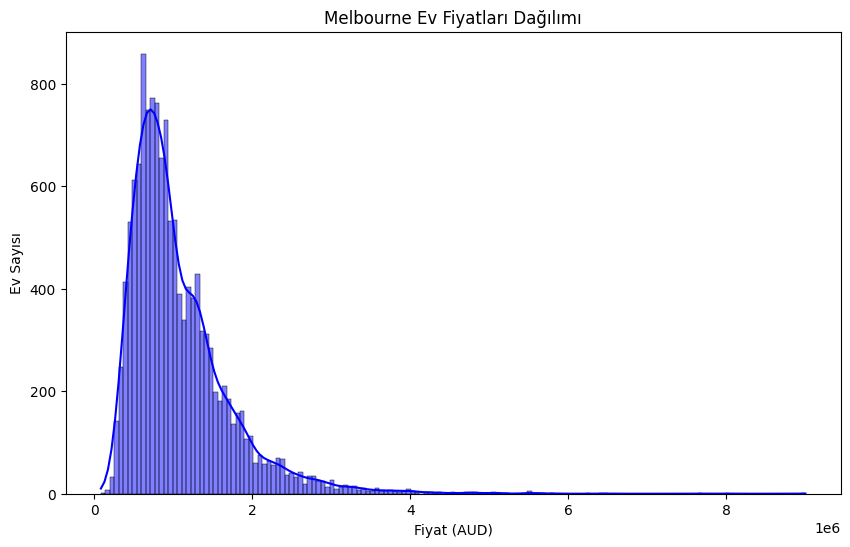

In [4]:
plt.figure(figsize=(10, 6))

# Fiyat dağılımını çizelim.
sns.histplot(df['Price'], kde=True, color='blue')

plt.title('Melbourne Ev Fiyatları Dağılımı')
plt.xlabel('Fiyat (AUD)')
plt.ylabel('Ev Sayısı')
plt.show()

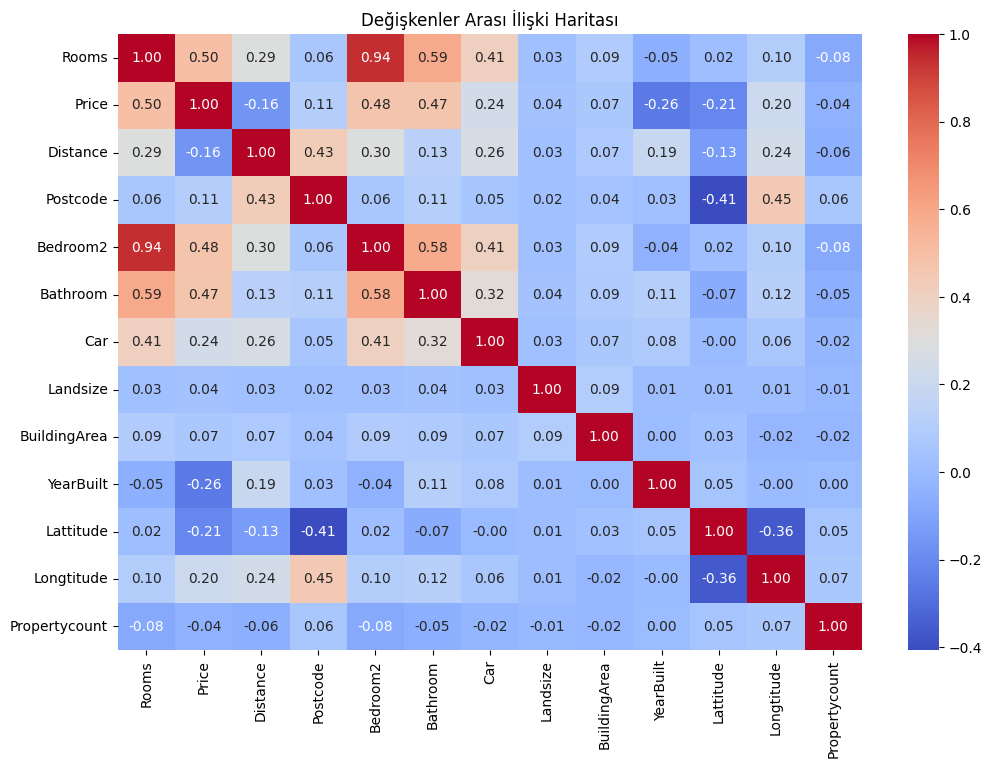

In [5]:
numeric_df = df.select_dtypes(include=['number'])

# Korelasyonu hesaplayalım.
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Değişkenler Arası İlişki Haritası')
plt.show()

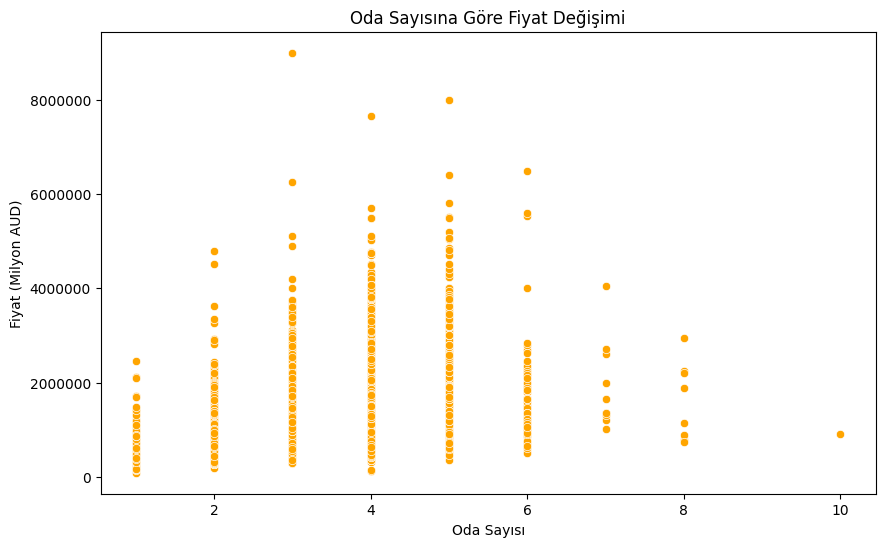

In [6]:
# Oda Sayısı ve Fiyat Arasındaki İlişkiyi Çizelim (Scatter Plot).
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rooms', y='Price', data=df, color='orange')

plt.title('Oda Sayısına Göre Fiyat Değişimi')
plt.xlabel('Oda Sayısı')
plt.ylabel('Fiyat (Milyon AUD)')

plt.ticklabel_format(style='plain', axis='y') 
plt.show()

In [8]:
# ---model kuralım---

y = df.Price

# Fiyatı en çok etkileyen özellikleri seçelim
features = ['Rooms', 'Bathroom', 'Landsize', 'BuildingArea', 
            'YearBuilt', 'Lattitude', 'Longtitude']

X = df[features]

print("Sorular (X) hazır mı?")
display(X.head())

print("\nCevaplar (y) hazır mı?")
print(y.head())

Sorular (X) hazır mı?


,Rooms,Bathroom,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude
0,2,1.0,202.0,126.0,1970.0,-37.7996,144.9984
1,2,1.0,156.0,79.0,1900.0,-37.8079,144.9934
2,3,2.0,134.0,150.0,1900.0,-37.8093,144.9944
3,3,2.0,94.0,126.0,1970.0,-37.7969,144.9969
4,4,1.0,120.0,142.0,2014.0,-37.8072,144.9941



Cevaplar (y) hazır mı?
0    1480000.0
1    1035000.0
2    1465000.0
3     850000.0
4    1600000.0
Name: Price, dtype: float64


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

#Karar Ağacı Modeli kullanacağız.
model = DecisionTreeRegressor(random_state=1)

model.fit(train_X, train_y)

print("Tebrikler! Model başarıyla eğitildi. ")

Tebrikler! Model başarıyla eğitildi. 


In [11]:
tahmin = model.predict(val_X)

#Gerçek cevaplarla karşılaştırıp hatayı ölçelim.
mae = mean_absolute_error(val_y, tahmin)

print(f"Ortalama Hata Payımız: ${mae:,.0f}")

Ortalama Hata Payımız: $233,286


In [12]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=1)

rf_model.fit(train_X, train_y)

rf_tahmin = rf_model.predict(val_X)

rf_mae = mean_absolute_error(val_y, rf_tahmin)

# karar ağaçları ile karsilastiralim
print(f"1. Model (Tek Ağaç) Hatası : ${mae:,.0f}")
print(f"2. Model (Orman) Hatası    : ${rf_mae:,.0f}")
print("-" * 30)
print(f"İyileşme (Fark)            : ${mae - rf_mae:,.0f} daha az hata! ")

1. Model (Tek Ağaç) Hatası : $233,286
2. Model (Orman) Hatası    : $168,881
------------------------------
İyileşme (Fark)            : $64,405 daha az hata! 


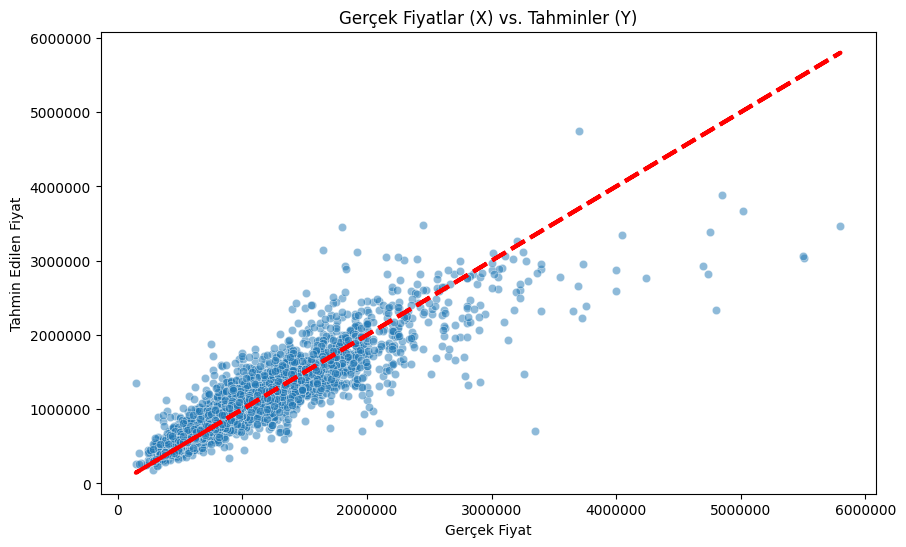

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(x=val_y, y=rf_tahmin, alpha=0.5)

m, b = np.polyfit(val_y, val_y, 1)
plt.plot(val_y, m*val_y + b, color='red', linestyle='--', linewidth=3)

plt.title('Gerçek Fiyatlar (X) vs. Tahminler (Y)')
plt.xlabel('Gerçek Fiyat')
plt.ylabel('Tahmin Edilen Fiyat')
plt.ticklabel_format(style='plain', axis='both') 
plt.show()

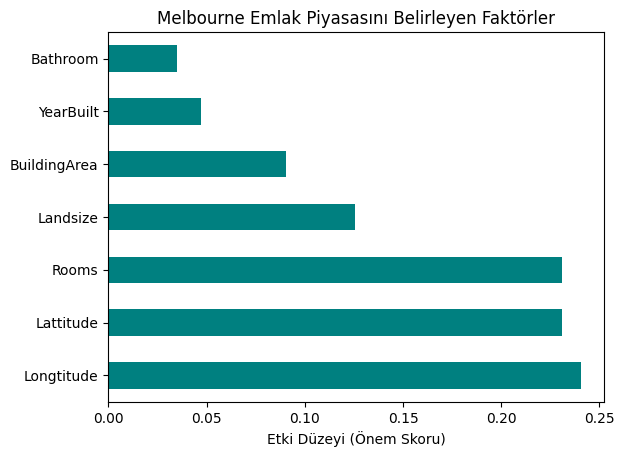

In [15]:
# Hangi özellik fiyatı ne kadar etkiliyor?
onem_dereceleri = pd.Series(rf_model.feature_importances_, index=X.columns)

onem_dereceleri.sort_values(ascending=False).plot(kind='barh', color='teal')

plt.title('Melbourne Emlak Piyasasını Belirleyen Faktörler')
plt.xlabel('Etki Düzeyi (Önem Skoru)')
plt.show()

In [16]:
# --- GELECEĞİ TAHMİN ETME MODÜLÜ ---

yeni_ev = {
    'Rooms': 3,        
    'Bathroom': 2,       
    'Landsize': 450,     
    'BuildingArea': 120, 
    'YearBuilt': 2015,   
    'Lattitude': -37.8,  
    'Longtitude': 144.9  
}

yeni_ev_df = pd.DataFrame([yeni_ev])

tahmini_fiyat = rf_model.predict(yeni_ev_df)

print("------------------------------------------------------")
print(f" Özellikleri girilen bu evin Tahmini Değeri:")
print(f" ${tahmini_fiyat[0]:,.0f}")
print("------------------------------------------------------")

------------------------------------------------------
 Özellikleri girilen bu evin Tahmini Değeri:
 $1,011,780
------------------------------------------------------
